In [8]:
import pandas as pd
import numpy as np

In [9]:
df = pd.read_csv("combined_concrete_data.csv")

df.head()

,binder,extra water,alkaline solution,molarity of mix,fine aggregate,coarse aggregate,age,curing temperature,compressive strength,water,pozzolan,foaming agent,density,concrete type,water binder ratio
0,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,30.0,NaN,NaN,NaN,NaN,0,0.500000
1,444.0,43.0,155.0,14.0,630.0,1170.0,1.0,75.0,30.0,NaN,NaN,NaN,NaN,0,0.445946
2,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,40.0,NaN,NaN,NaN,NaN,0,0.500000
3,428.0,43.0,171.0,14.0,630.0,1170.0,1.0,75.0,28.0,NaN,NaN,NaN,NaN,0,0.500000
4,428.0,43.0,171.0,14.0,630.0,1170.0,2.0,75.0,32.0,NaN,NaN,NaN,NaN,0,0.500000


In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
binder,2600.0,444.672208,136.268401,107.200000,400.000000,405.000000,468.000000,992.800000
extra water,1691.0,17.955802,26.448564,0.000000,0.000000,0.000000,32.000000,128.570000
alkaline solution,1691.0,187.283390,36.738527,106.680000,160.020000,180.000000,200.000000,294.400000
molarity of mix,1691.0,11.519456,2.776044,4.100000,10.000000,12.000000,14.000000,20.000000
fine aggregate,2600.0,631.342854,178.804817,0.000000,550.000000,645.000000,697.400000,1098.000000
coarse aggregate,1691.0,1099.968297,188.269756,647.800000,989.500000,1181.000000,1220.350000,1369.000000
age,2600.0,25.490000,22.438885,1.000000,7.000000,28.000000,28.000000,91.000000
curing temperature,1691.0,34.972797,16.904233,20.000000,27.000000,27.000000,28.000000,80.000000
compressive strength,2600.0,29.266384,21.230027,0.080000,10.422500,26.735575,43.745000,110.000000
water,909.0,232.404999,83.601458,68.900000,169.000000,234.000000,290.325000,484.000000


I am going to train with the models, which innately support NANs in the dataset(lightgbm, xgboost), and then impute 0 valuse to the NANs and train other models.

In [10]:
target = "compressive strength"

X = df.drop(columns=[target])
y = df[target]

In [11]:
from sklearn.model_selection import train_test_split

# 80/20 split
X_train_ori, X_test_ori, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=df['concrete type'] 
)

print(f"Train: {X_train_ori.shape}, Test: {X_test_ori.shape}")

# Keep original unscaled data for reference
X_train_original_unscaled = X_train_ori.copy()
X_test_original_unscaled = X_test_ori.copy()

Train: (2080, 14), Test: (520, 14)


In [41]:
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pandas as pd

# ==========================================
# PATH 1: For XGBoost / LightGBM / CatBoost 
# Objective: Scale the data (handles NaNs natively)
# ==========================================
X_train = X_train_ori.copy()      # NaNs stay
X_test  = X_test_ori.copy()
# ==========================================
# PATH 2: For Random Forest / Gradient Boosting 
# Objective: Impute FIRST on original unscaled data, THEN scale
# ==========================================
imputer_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

X_train_imputed = pd.DataFrame(
    imputer_pipeline.fit_transform(X_train_ori),
    columns=X_train_ori.columns
)

X_test_imputed = pd.DataFrame(
    imputer_pipeline.transform(X_test_ori),
    columns=X_test_ori.columns
)

print(f"Path 1 (Scaled, NaN-aware models) -> Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Path 2 (Zero Imputed + Scaled)    -> Train: {X_train_imputed.shape}, Test: {X_test_imputed.shape}")


Path 1 (Scaled, NaN-aware models) -> Train: (2080, 14), Test: (520, 14)
Path 2 (Zero Imputed + Scaled)    -> Train: (2080, 14), Test: (520, 14)


In [43]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [5]:
import joblib
import os
import optuna
from sklearn.model_selection import cross_val_score, KFold
import logging
import json

os.makedirs('saved_models/combined_dataset_regression_research_models', exist_ok=True)

In [2]:
def load_or_train_model(model_name, train_logic_func):
    """
    Checks if a model exists. If it does, loads it. 
    If not, runs the provided training logic and saves the model.
    """
    directory = 'saved_models/combined_dataset_regression_research_models'
    model_path = f'{directory}/{model_name}.pkl'
    model_config_path = f'{directory}/{model_name}.json'

    if os.path.exists(model_path):
        print(f"[{model_name}] Found saved model. Loading...")
        return joblib.load(model_path)
    else:
        print(f"[{model_name}] No saved model found. Training now...")
        
        # Execute the training function
        trained_model, trained_model_params = train_logic_func()
        
        # Save after training
        os.makedirs('saved_models', exist_ok=True)
        joblib.dump(trained_model, model_path)
        with open(model_config_path, 'w') as f:
            json.dump(trained_model_params, f, indent=4)
        print(f"[{model_name}] Training complete and model saved!\n")
        
        return trained_model

In [46]:
# XGB REGRESSOR
def train_grid_xgb():
    xgb_model = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        missing=np.nan,           
        enable_categorical=True   
    )

    param_grid_xgb = {
        'n_estimators': [300, 500],
        'max_depth': [5, 7, 9],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8, 1.0]
    }

    grid_search_xgb = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid_xgb,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )
    grid_search_xgb.fit(X_train_ori, y_train)

    best_xgb_model = grid_search_xgb.best_estimator_

    best_xgb_params = grid_search_xgb.best_params_
    return best_xgb_model, best_xgb_params

In [47]:
# LGBM REGRESSOR

def train_grid_lgbm():

    def lgbm_objective(trial):
        params = {
            # Search space
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'boosting_type': 'gbdt',
            'verbose': -1,
            'random_state': 42,
            'n_jobs': -1 # Let LightGBM use all cores
        }
        
        model = LGBMRegressor(**params)
        
        # Example using 5-fold CV for speed during tuning
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(model, X_train_ori, y_train, cv=cv, scoring='neg_mean_squared_error', n_jobs=1)
        
        return scores.mean()

    study_lgbm = optuna.create_study(direction='maximize')
    study_lgbm.optimize(lgbm_objective, n_trials=150, show_progress_bar=False) 

    best_lgbm_params = study_lgbm.best_params

    best_lgbm_model = LGBMRegressor(
        boosting_type="gbdt",
        random_state=42,
        verbose=-1,
        **best_lgbm_params
        )

    best_lgbm_model.fit(X_train_ori, y_train) 

    return best_lgbm_model, best_lgbm_params  




I implemented the optuna hyperparameter tuning for lightgbm, and it is giving me a good boost in the performance. I will implement it for xgboost as well, and then move on to the imputation part. I implemented the optuna hyperparameter tuning, because the gridsearchcv was taking a lot of time to run, like 5 candidates initialization in gridsearchcv was taking around 5.37 ish minutes, and I had around 125+ candidates to try. So optune is a good choice for hyperparameter tuning in this case, because it is much faster than gridsearchcv, and it also gives better results. I will not implement it to others (for now), if situation arises, I will turn to optuna.

In [3]:
# CATBOOST REGRESSOR
import optuna
from sklearn.model_selection import cross_val_score, KFold
from catboost import CatBoostRegressor

def train_grid_catboost():

    def catboost_objective(trial):
        params = {
            # Optuna Search Space (mapped from your GridSearchCV boundaries)
            'iterations': trial.suggest_int('iterations', 300, 800),
            'depth': trial.suggest_int('depth', 6, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'subsample': trial.suggest_float('subsample', 0.4, 1.0),
            
            # Fixed parameters
            'random_state': 42,
            'verbose': 0
        }
        
        model = CatBoostRegressor(**params)
        
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        
        scores = cross_val_score(
            model, 
            X_train_ori, 
            y_train, 
            cv=cv, 
            scoring='neg_mean_squared_error', 
            n_jobs=-1
        )
        
        return scores.mean()

    study_catboost = optuna.create_study(direction='maximize')
    
    study_catboost.optimize(catboost_objective, n_trials=50, show_progress_bar=False) 

    best_catboost_params = study_catboost.best_params

    best_catboost_model = CatBoostRegressor(
        random_state=42,
        verbose=0,
        **best_catboost_params
    )

    best_catboost_model.fit(X_train_ori, y_train)

    return best_catboost_model, best_catboost_params


In [49]:
# GRADIENT BOOSTING REGRESSOR

def train_grid_gradient_boost():
    model = GradientBoostingRegressor(random_state=42)

    param_grid_gbr = {'n_estimators': [200, 300, 400, 500], 'max_depth': [3,5,7,9],
                'learning_rate': [0.01, 0.05, 0.1]}

    grid_gradient_boost = GridSearchCV(model, param_grid_gbr, cv=5, scoring='r2', n_jobs=-1, verbose=1)
    grid_gradient_boost.fit(X_train_imputed, y_train)
    
    best_model_gradient_boost = grid_gradient_boost.best_estimator_
    best_gradient_boost_params = grid_gradient_boost.best_params_

    return best_model_gradient_boost, best_gradient_boost_params

In [50]:
# RANDOMFOREST REGRESSOR
def train_grid_random_forest():
    model = RandomForestRegressor(random_state=42, n_jobs=-1)

    param_grid_rf = {'n_estimators': [200, 300], 'max_depth': [10, 15, 20],
                'min_samples_split': [2, 5, 7, 9], 'min_samples_leaf': [1, 2, 4, 6]}

    grid_random_forest = GridSearchCV(model, param_grid_rf, cv=5, scoring='r2', n_jobs=-1, verbose=1)
    grid_random_forest.fit(X_train_imputed, y_train)
    
    best_model_rf = grid_random_forest.best_estimator_
    best_rf_params = grid_random_forest.best_params_

    return best_model_rf, best_rf_params

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2 Score": r2_score(y_true, y_pred)
    }

## load all the models (or train if not found)

In [93]:
# XGB REGRESSOR load or train

xgb_model = load_or_train_model("xgb_regressor", train_grid_xgb)

[xgb_regressor] Found saved model. Loading...


In [94]:
# LGBM REGRESSOR load or train

lgbm_model = load_or_train_model("lgbm_regressor", train_grid_lgbm)

[lgbm_regressor] Found saved model. Loading...


In [6]:
# CatBoost REGRESSOR load or train

catboost_model = load_or_train_model("catboost_regressor", train_grid_catboost)

[catboost_regressor] Found saved model. Loading...


In [96]:
# Gradient Boosting REGRESSOR load or train

gradient_boost_model = load_or_train_model("gradient_boost_regressor", train_grid_gradient_boost)

[gradient_boost_regressor] Found saved model. Loading...


In [97]:
# Random Forest REGRESSOR load or train

random_forest_model = load_or_train_model("random_forest_regressor", train_grid_random_forest)

[random_forest_regressor] Found saved model. Loading...


In [98]:
y_pred_xgb = xgb_model.predict(X_test_ori)

xgb_eval = evaluate_model(y_test, y_pred_xgb)

print("xgb eval:",xgb_eval)

xgb eval: {'RMSE': np.float64(7.37046966311945), 'MSE': 54.32382305496414, 'MAE': 3.6404194453784315, 'R2 Score': 0.8912557138754649}


In [100]:
y_pred_catboost = catboost_model.predict(X_test_ori)

catboost_eval = evaluate_model(y_test, y_pred_catboost)

print("catboost eval:",catboost_eval)

catboost eval: {'RMSE': np.float64(7.188174207457794), 'MSE': 51.669848436761484, 'MAE': 3.5415967129261245, 'R2 Score': 0.8965683844317525}


In [101]:
y_pred_lgbm = lgbm_model.predict(X_test_ori)

lgbm_eval = evaluate_model(y_test, y_pred_lgbm)

print("lgbm eval:",lgbm_eval)

lgbm eval: {'RMSE': np.float64(7.539342249948027), 'MSE': 56.84168156185138, 'MAE': 3.8217487298993364, 'R2 Score': 0.886215517687192}


In [102]:
y_pred_gradient_boost = gradient_boost_model.predict(X_test_imputed)

gradient_boost_eval = evaluate_model(y_test ,y_pred_gradient_boost)

print("gb eval:",gradient_boost_eval)

gb eval: {'RMSE': np.float64(7.487430721342475), 'MSE': 56.061618806903105, 'MAE': 3.7804873930422005, 'R2 Score': 0.8877770308990541}


In [103]:
y_pred_rf = random_forest_model.predict(X_test_imputed)

rf_eval = evaluate_model(y_test, y_pred_rf)

print("rf eval:",rf_eval)

rf eval: {'RMSE': np.float64(8.105920687901445), 'MSE': 65.70595019854865, 'MAE': 4.087637883313923, 'R2 Score': 0.8684712112171107}


In [107]:
eval_table = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM", "CatBoost", "Gradient Boosting", "Random Forest"],
    "RMSE": [xgb_eval["RMSE"], lgbm_eval["RMSE"], catboost_eval["RMSE"], gradient_boost_eval["RMSE"], rf_eval["RMSE"]],
    "R2 Score": [xgb_eval["R2 Score"], lgbm_eval["R2 Score"], catboost_eval["R2 Score"], gradient_boost_eval["R2 Score"], rf_eval["R2 Score"]],
    "MAE": [xgb_eval["MAE"], lgbm_eval["MAE"], catboost_eval["MAE"], gradient_boost_eval["MAE"], rf_eval["MAE"]],
    "MSE": [xgb_eval["MSE"], lgbm_eval["MSE"], catboost_eval["MSE"], gradient_boost_eval["MSE"], rf_eval["MSE"]]
})

eval_table

,Model,RMSE,R2 Score,MAE,MSE
0,XGBoost,7.370470,0.891256,3.640419,54.323823
1,LightGBM,7.539342,0.886216,3.821749,56.841682
2,CatBoost,7.188174,0.896568,3.541597,51.669848
3,Gradient Boosting,7.487431,0.887777,3.780487,56.061619
4,Random Forest,8.105921,0.868471,4.087638,65.705950


In [62]:
# visualization of results

results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM", "CatBoost", "Gradient Boosting", "Random Forest"],
    "RMSE": [xgb_eval["RMSE"], lgbm_eval["RMSE"], catboost_eval["RMSE"], gradient_boost_eval["RMSE"], rf_eval["RMSE"]],
    "MAE": [xgb_eval["MAE"], lgbm_eval["MAE"], catboost_eval["MAE"], gradient_boost_eval["MAE"], rf_eval["MAE"]],
    "MSE": [xgb_eval["MSE"], lgbm_eval["MSE"], catboost_eval["MSE"], gradient_boost_eval["MSE"], rf_eval["MSE"]],
    "R2 Score": [xgb_eval["R2 Score"], lgbm_eval["R2 Score"], catboost_eval["R2 Score"], gradient_boost_eval["R2 Score"], rf_eval["R2 Score"]]
})

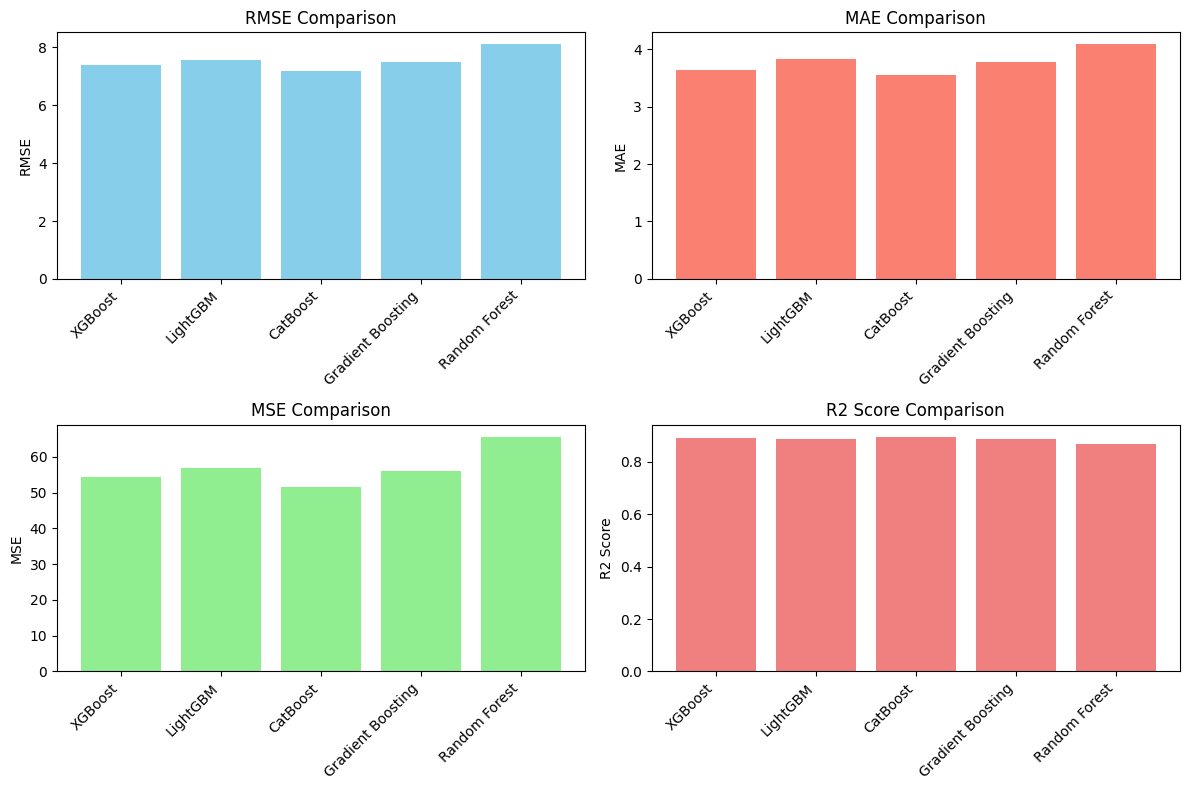

In [63]:
# combined comparison table

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

models = results["Model"].to_list()

plot_data = {
    "RMSE": 'skyblue',
    "MAE": 'salmon',
    "MSE": 'lightgreen',
    "R2 Score": 'lightcoral'
}

for ax, (metric, color) in zip(axes.flatten(), plot_data.items()):
	ax.bar(models, results[metric], color=color)
	ax.set_title(f'{metric} Comparison')
	ax.set_xticks(range(len(models)))
	ax.set_xticklabels(models, rotation=45, ha='right')
	ax.set_ylabel(metric)
	
plt.tight_layout()
plt.show()

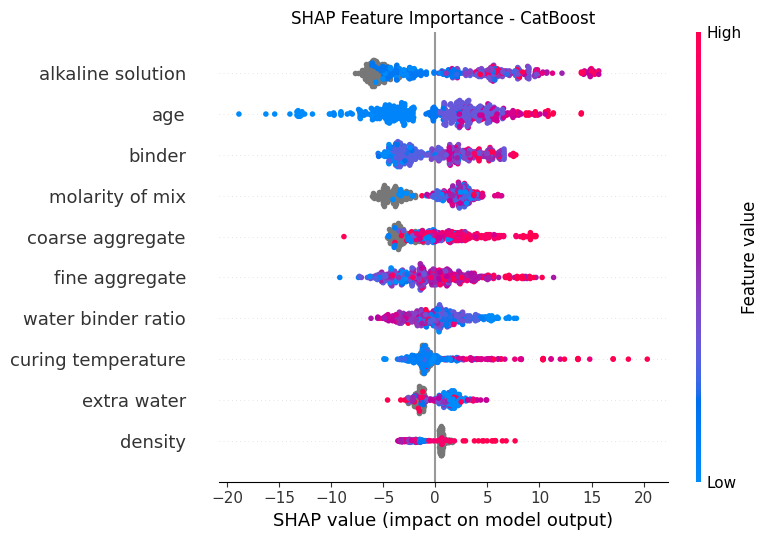

<Figure size 800x600 with 0 Axes>

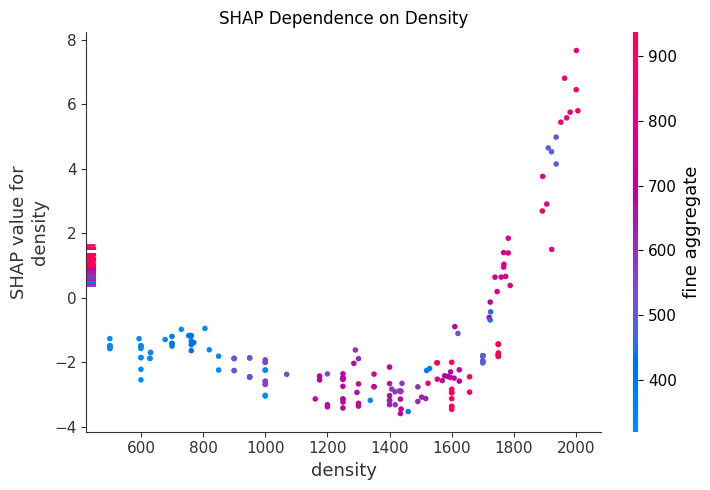

<Figure size 800x600 with 0 Axes>

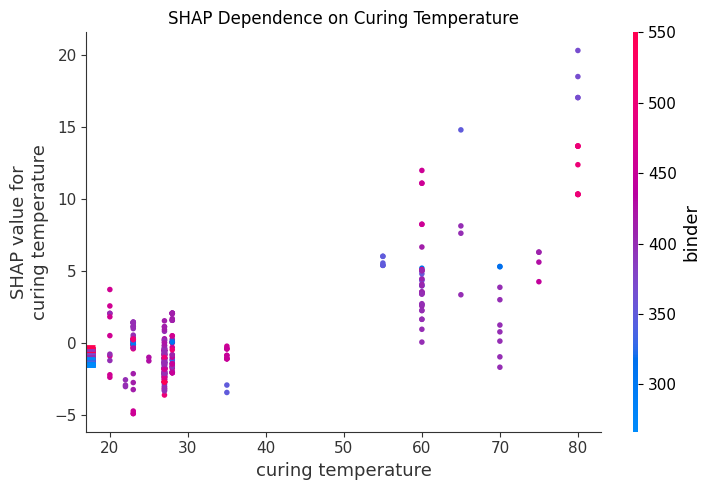

<Figure size 800x600 with 0 Axes>

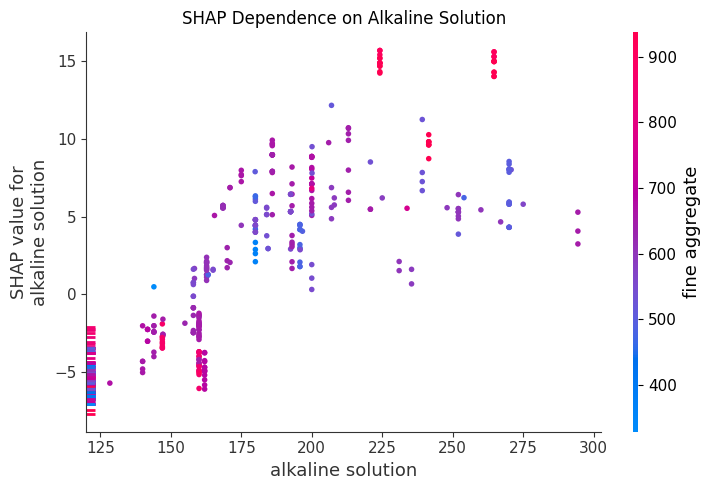

<Figure size 800x600 with 0 Axes>

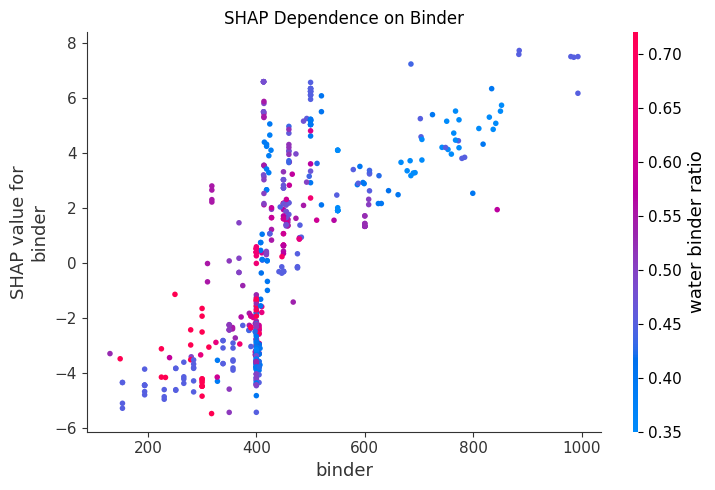

<Figure size 640x480 with 0 Axes>

In [16]:
import shap
import matplotlib.pyplot as plt

# Choose one model at a time
model = catboost_model        # or best_xgboost
model_name = "CatBoost"      # or "XGBoost"
X_test_use = X_test_ori.copy()   # the native NaN-preserving test set

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_use)

# 1. Global SHAP summary (most important plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_use, max_display=10, show=False)
plt.title(f'SHAP Feature Importance - {model_name}')
plt.tight_layout()
plt.show()

# 2. SHAP dependence plots for key features (to see domain behaviour)
plt.figure(figsize=(8, 6))
shap.dependence_plot('density', shap_values, X_test_use, show=False)
plt.title('SHAP Dependence on Density')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
shap.dependence_plot('curing temperature', shap_values, X_test_use, show=False)
plt.title('SHAP Dependence on Curing Temperature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
shap.dependence_plot('alkaline solution', shap_values, X_test_use, show=False)
plt.title('SHAP Dependence on Alkaline Solution')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
shap.dependence_plot('binder', shap_values, X_test_use, show=False)
plt.title('SHAP Dependence on Binder')
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

PermutationExplainer explainer: 521it [00:39,  8.87it/s]                         
/tmp/ipykernel_30769/1964996009.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_use, max_display=15, show=False)


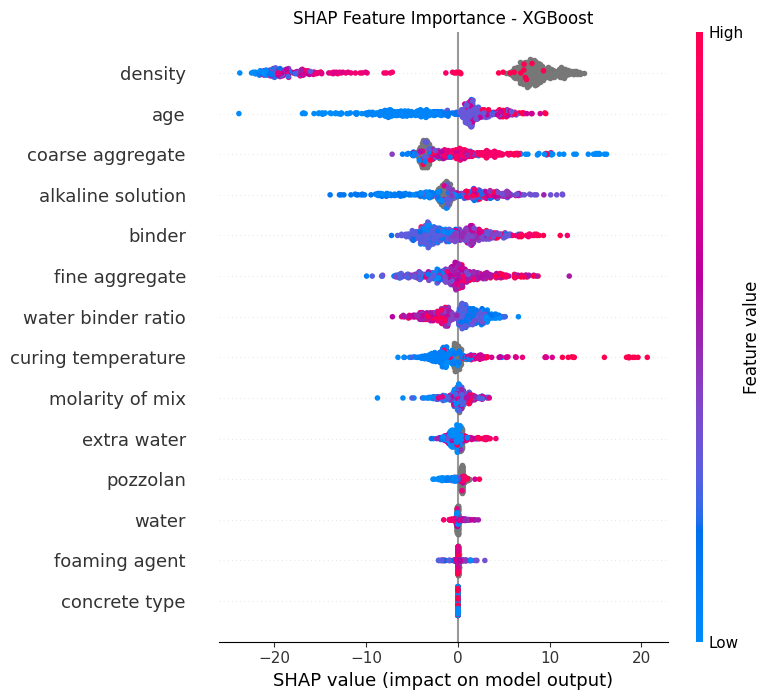

In [83]:
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Choose one model at a time
model = xgb_model        
model_name = "XGBoost"      
X_test_use = X_test_ori.copy()   

# Use PermutationExplainer instead - works with any model and avoids SHAP/XGBoost compatibility issues
explainer = shap.PermutationExplainer(model.predict, X_test_use)
shap_values = explainer.shap_values(X_test_use)

# 1. Global SHAP summary (most important plot)
shap.summary_plot(shap_values, X_test_use, max_display=15, show=False)
plt.title(f'SHAP Feature Importance - {model_name}')
plt.tight_layout()
plt.show()


/tmp/ipykernel_30769/2199698024.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_use, max_display=15, show=False)


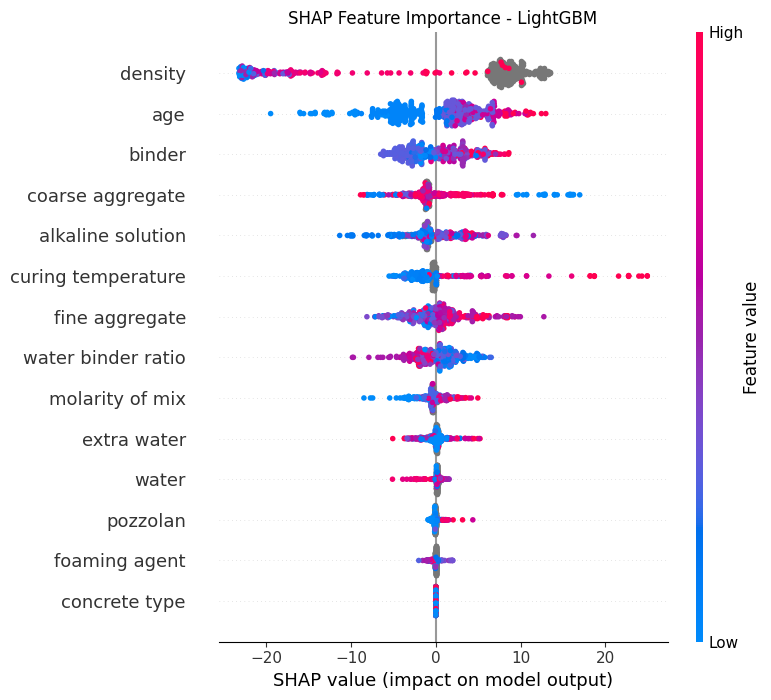

In [84]:
import shap
import matplotlib.pyplot as plt

# Choose one model at a time
model = lgbm_model        # or best_xgboost
model_name = "LightGBM"      # or "XGBoost"
X_test_use = X_test_ori.copy()   # the native NaN-preserving test set

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_use)

# 1. Global SHAP summary (most important plot)
shap.summary_plot(shap_values, X_test_use, max_display=15, show=False)
plt.title(f'SHAP Feature Importance - {model_name}')
plt.tight_layout()
plt.show()

/tmp/ipykernel_30769/105812595.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_use, max_display=15, show=False)


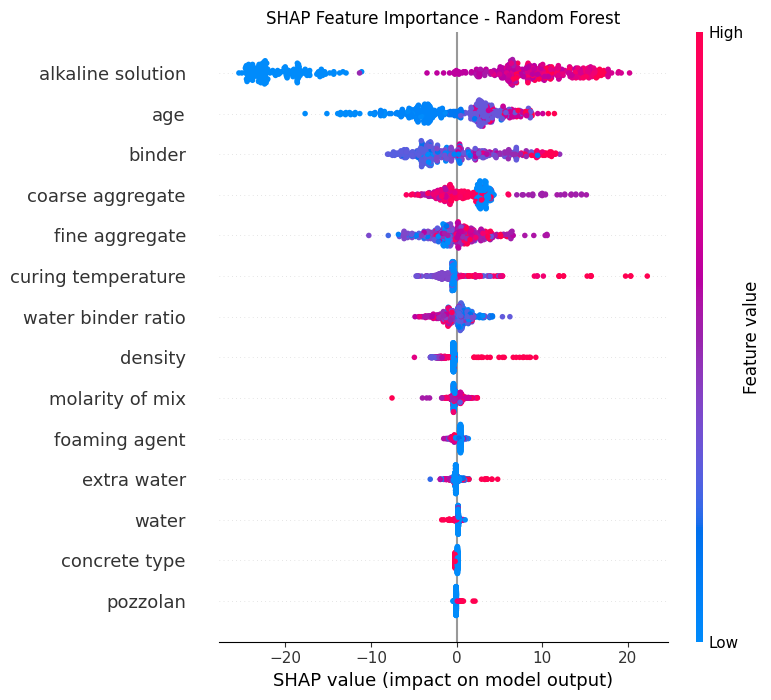

In [85]:
import shap
import matplotlib.pyplot as plt

# Choose one model at a time
model = random_forest_model        # or best_xgboost
model_name = "Random Forest"      # or "XGBoost"
X_test_use = X_test_imputed.copy()   # the native NaN-preserving test set

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_use)

# 1. Global SHAP summary (most important plot)
shap.summary_plot(shap_values, X_test_use, max_display=15, show=False)
plt.title(f'SHAP Feature Importance - {model_name}')
plt.tight_layout()
plt.show()

/tmp/ipykernel_30769/2168126805.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_use, max_display=15, show=False)


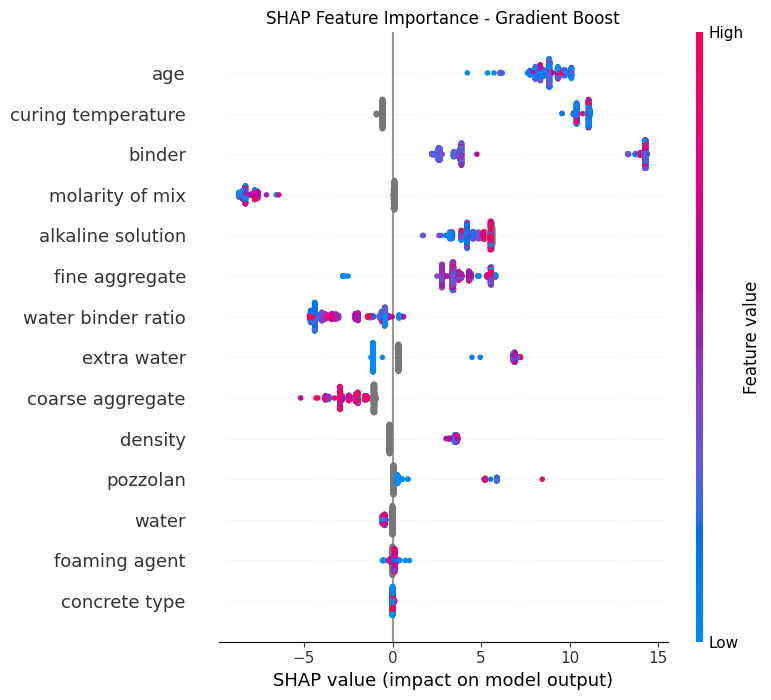

In [86]:
import shap
import matplotlib.pyplot as plt

# Choose one model at a time
model = gradient_boost_model        # or best_xgboost
model_name = "Gradient Boost"      # or "XGBoost"
X_test_use = X_test_ori.copy()   # the native NaN-preserving test set

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_use)

# 1. Global SHAP summary (most important plot)
shap.summary_plot(shap_values, X_test_use, max_display=15, show=False)
plt.title(f'SHAP Feature Importance - {model_name}')
plt.tight_layout()
plt.show()

In [15]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

model = catboost_model          # your trained CatBoost model
model_name = "CatBoost"
X_test_use = X_test_ori.copy()     # native test set (with NaNs)

y_pred = model.predict(X_test_use)

# 1. Domain-specific performance
geo_mask = X_test_use['concrete type'] == 0
light_mask = X_test_use['concrete type'] == 1

print(f"=== {model_name} - FINAL DOMAIN PERFORMANCE ===")
print(f"Overall R²           : {r2_score(y_test, y_pred):.4f}")
print(f"Geopolymer-only R²   : {r2_score(y_test[geo_mask], y_pred[geo_mask]):.4f}")
print(f"Lightweight-only R²  : {r2_score(y_test[light_mask], y_pred[light_mask]):.4f}")
print(f"RMSE                 : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} MPa")
print(f"RMSE (Geopolymer)    : {np.sqrt(mean_squared_error(y_test[geo_mask], y_pred[geo_mask])):.2f} MPa")
print(f"RMSE (Lightweight)   : {np.sqrt(mean_squared_error(y_test[light_mask], y_pred[light_mask])):.2f} MPa")
print(f"MAE                  : {mean_absolute_error(y_test, y_pred):.2f} MPa")
print(f"MAE (Geopolymer)     : {mean_absolute_error(y_test[geo_mask], y_pred[geo_mask]):.2f} MPa")
print(f"MAE (Lightweight)    : {mean_absolute_error(y_test[light_mask], y_pred[light_mask]):.2f} MPa")


=== CatBoost - FINAL DOMAIN PERFORMANCE ===
Overall R²           : 0.8966
Geopolymer-only R²   : 0.7959
Lightweight-only R²  : 0.9829
RMSE                 : 7.19 MPa
RMSE (Geopolymer)    : 8.85 MPa
RMSE (Lightweight)   : 1.49 MPa
MAE                  : 3.54 MPa
MAE (Geopolymer)     : 4.94 MPa
MAE (Lightweight)    : 0.95 MPa


=== CatBoost - FINAL DOMAIN PERFORMANCE ===
Overall R²           : 0.8966
Geopolymer-only R²   : 0.7959
Lightweight-only R²  : 0.9829
RMSE                 : 7.19 MPa
MAE                  : 3.54 MPa


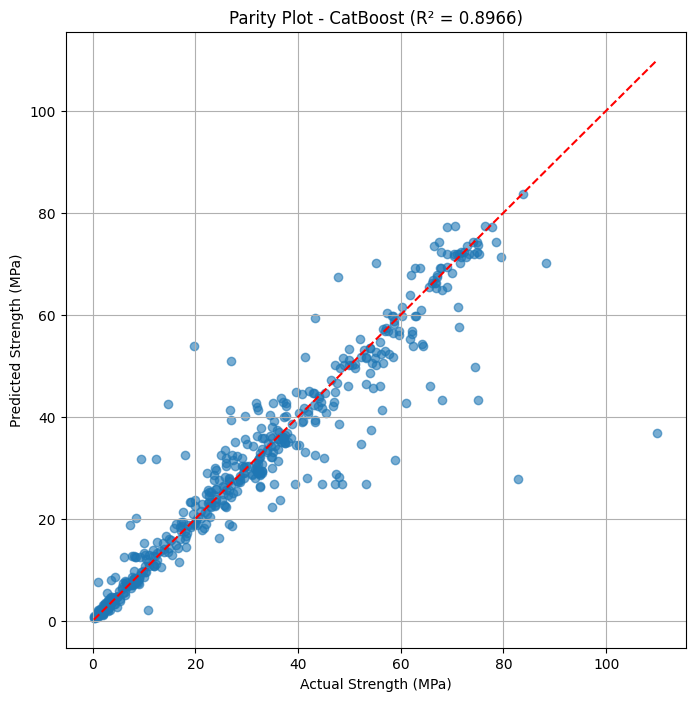

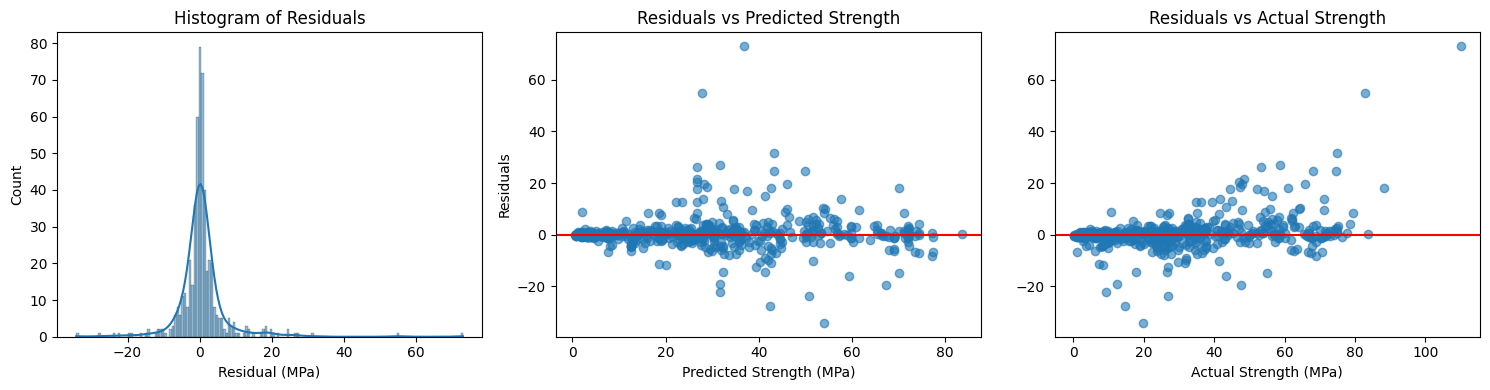

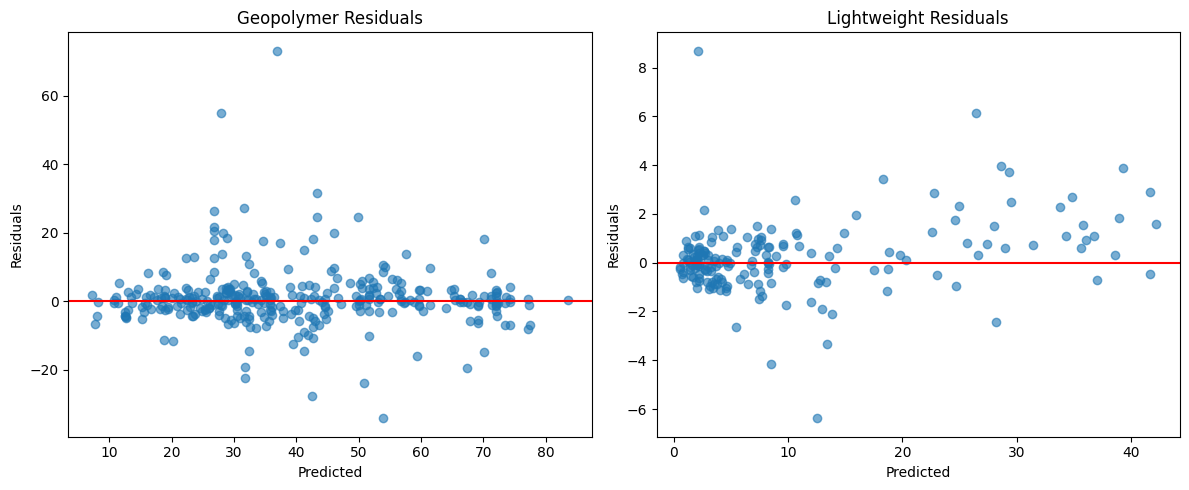

Bootstrapping completed - 95% prediction intervals ready


In [ ]:
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ==================== CATBOOST FINAL EVALUATION ====================
model = catboost_model          # your trained CatBoost model
model_name = "CatBoost"
X_test_use = X_test_ori.copy()     # native test set (with NaNs)

y_pred = model.predict(X_test_use)

# 1. Domain-specific performance
geo_mask = X_test_use['concrete type'] == 0
light_mask = X_test_use['concrete type'] == 1

print(f"=== {model_name} - FINAL DOMAIN PERFORMANCE ===")
print(f"Overall R²           : {r2_score(y_test, y_pred):.4f}")
print(f"Geopolymer-only R²   : {r2_score(y_test[geo_mask], y_pred[geo_mask]):.4f}")
print(f"Lightweight-only R²  : {r2_score(y_test[light_mask], y_pred[light_mask]):.4f}")
print(f"RMSE                 : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} MPa")
print(f"RMSE (Geopolymer)    : {np.sqrt(mean_squared_error(y_test[geo_mask], y_pred[geo_mask])):.2f} MPa")
print(f"RMSE (Lightweight)   : {np.sqrt(mean_squared_error(y_test[light_mask], y_pred[light_mask])):.2f} MPa")
print(f"MAE                  : {mean_absolute_error(y_test, y_pred):.2f} MPa")
print(f"MAE (Geopolymer)     : {mean_absolute_error(y_test[geo_mask], y_pred[geo_mask]):.2f} MPa")
print(f"MAE (Lightweight)    : {mean_absolute_error(y_test[light_mask], y_pred[light_mask]):.2f} MPa")

# 2. Parity Plot
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title(f'Parity Plot - {model_name} (R² = {r2_score(y_test, y_pred):.4f})')
plt.grid(True)
plt.show()

# 3. Residual Analysis
residuals = y_test - y_pred

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residual (MPa)')

plt.subplot(1, 3, 2)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red')
plt.title('Residuals vs Predicted Strength')
plt.xlabel('Predicted Strength (MPa)')
plt.ylabel('Residuals')

plt.subplot(1, 3, 3)
plt.scatter(y_test, residuals, alpha=0.6)
plt.axhline(0, color='red')
plt.title('Residuals vs Actual Strength')
plt.xlabel('Actual Strength (MPa)')
plt.tight_layout()
plt.show()

# 4. Domain-specific Residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_pred[geo_mask], residuals[geo_mask], alpha=0.6)
axes[0].axhline(0, color='red')
axes[0].set_title('Geopolymer Residuals')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')

axes[1].scatter(y_pred[light_mask], residuals[light_mask], alpha=0.6)
axes[1].axhline(0, color='red')
axes[1].set_title('Lightweight Residuals')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

# 5. Bootstrapping for 95% Prediction Intervals (Mandal-style)
n_boot = 200
boot_preds = np.zeros((n_boot, len(X_test_use)))

for i in range(n_boot):
    idx = np.random.choice(len(X_train_ori), len(X_train_ori), replace=True)
    boot_model = model.__class__(**model.get_params())
    boot_model.fit(X_train_ori.iloc[idx], y_train.iloc[idx])
    boot_preds[i] = boot_model.predict(X_test_use)

lower_pi = np.percentile(boot_preds, 2.5, axis=0)
upper_pi = np.percentile(boot_preds, 97.5, axis=0)
mean_pred = boot_preds.mean(axis=0)

print("Bootstrapping completed - 95% prediction intervals ready")

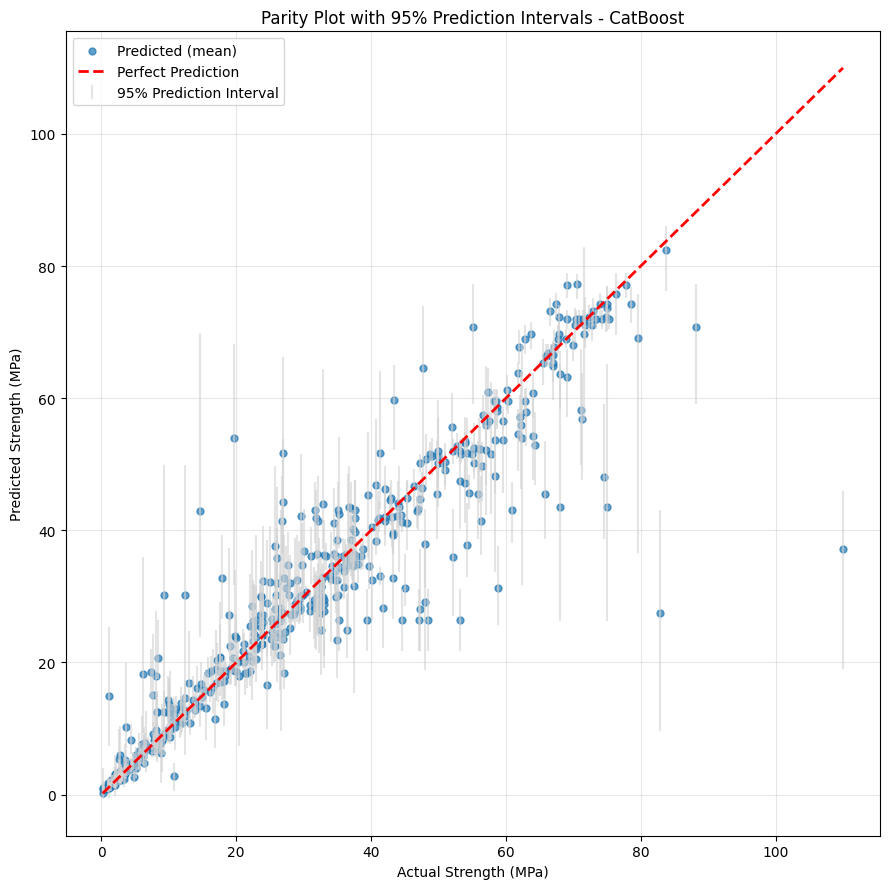

Bootstrapping + Parity plot with 95% intervals completed.


In [89]:
import numpy as np
import matplotlib.pyplot as plt

# ==================== PARITY PLOT WITH 95% CONFIDENCE INTERVALS ====================
plt.figure(figsize=(9, 9))

# Main parity points
plt.scatter(y_test, mean_pred, alpha=0.7, label='Predicted (mean)', s=25)

# 95% prediction interval error bars
plt.errorbar(y_test, mean_pred, yerr=[mean_pred - lower_pi, upper_pi - mean_pred],
             fmt='none', ecolor='lightgray', alpha=0.6, label='95% Prediction Interval')

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Strength (MPa)')
plt.ylabel('Predicted Strength (MPa)')
plt.title('Parity Plot with 95% Prediction Intervals - CatBoost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
